In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import json

In [82]:
file_path = '../../data/processed/data-new.json'
with open(file_path, "r") as file:
    data =json.load(file)

In [83]:
tree = pd.DataFrame(data['nodes'])

In [84]:
tree.head()

,id,name,thesis,school,country,year,subject,advisors,students
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]"
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]"
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[]
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[]
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[]


In [85]:
unique_subjects = tree["subject"].dropna().unique()

In [86]:
unique_subjects

array(['74—Mechanics of deformable solids', '62—Statistics',
       '68—Computer science', '08—General algebraic systems',
       '03—Mathematical logic and foundations',
       '06—Order, lattices, ordered algebraic structures',
       '65—Numerical analysis',
       '90—Operations research, mathematical programming',
       '44—Integral transforms, operational calculus',
       '97—Mathematics education',
       '82—Statistical mechanics, structure of matter',
       '76—Fluid mechanics', '54—General topology',
       '52—Convex and discrete geometry', '46—Functional analysis',
       '60—Probability theory and stochastic processes',
       '37—Dynamical systems and ergodic theory',
       '57—Manifolds and cell complexes',
       '34—Ordinary differential equations', '11—Number theory',
       '94—Information and communication, circuits',
       '20—Group theory and generalizations',
       '16—Associative rings and algebras',
       '30—Functions of a complex variable',
       '41—

In [87]:
sorted_subs = sorted(unique_subjects, key=lambda x: int(x.split("—")[0]))

In [88]:
subject_codes = [s.split("—")[0] for s in sorted_subs]
subject_names = [s.split("—")[1] for s in sorted_subs]
subjects = pd.DataFrame({
    "subject_Code": subject_codes,
    "subject_Name": subject_names
})

In [89]:
subjects

,subject_Code,subject_Name
0,00,General
1,01,History and biography
2,03,Mathematical logic and foundations
3,05,Combinatorics
4,06,"Order, lattices, ordered algebraic structures"
...,...,...
58,91,"Game theory, economics, social and behavioral ..."
59,92,Biology and other natural sciences
60,93,Systems theory; control
61,94,"Information and communication, circuits"


## Checking if there are subject areas with slight changes 

In [90]:
import re

def normalize_subject_name(name):
    if pd.isna(name):
        return None
    
    name = name.lower()
    name = name.replace("&", "and")
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    
    return name

subjects["subject_Name_clean"] = subjects["subject_Name"].apply(normalize_subject_name)

In [91]:
subjects.head()

,subject_Code,subject_Name,subject_Name_clean
0,00,General,general
1,01,History and biography,history and biography
2,03,Mathematical logic and foundations,mathematical logic and foundations
3,05,Combinatorics,combinatorics
4,06,"Order, lattices, ordered algebraic structures",order lattices ordered algebraic structures


In [92]:
subjects[subjects.duplicated("subject_Name_clean", keep=False)].sort_values("subject_Name_clean")

,subject_Code,subject_Name,subject_Name_clean


In [93]:
!pip install rapidfuzz

In [94]:
from rapidfuzz import fuzz

pairs = []

names = subjects[["subject_Code", "subject_Name", "subject_Name_clean"]].dropna()

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        row1 = names.iloc[i]
        row2 = names.iloc[j]
        
        score = fuzz.token_sort_ratio(
            row1["subject_Name_clean"],
            row2["subject_Name_clean"]
        )
        
        if score >= 80:
            pairs.append({
                "code_1": row1["subject_Code"],
                "name_1": row1["subject_Name"],
                "code_2": row2["subject_Code"],
                "name_2": row2["subject_Name"],
                "similarity": score
            })

similar_subjects = pd.DataFrame(pairs).sort_values("similarity", ascending=False)
similar_subjects

,code_1,name_1,code_2,name_2,similarity
1,16,Associative rings and algebras,17,Nonassociative rings and algebras,95.238095
3,34,Ordinary differential equations,35,Partial differential equations,85.245902
2,26,Real functions,33,Special functions,83.870968
0,13,Commutative rings and algebras,16,Associative rings and algebras,83.333333


In [95]:
tree["subject_code"] = tree["subject"].apply(lambda x: x.split("—")[0] if pd.notna(x) else None)
tree["subject_name"] = tree["subject"].apply(lambda x: x.split("—")[1] if pd.notna(x) else None)

In [96]:
tree.loc[tree["subject"].isna()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 136040 entries, 1 to 338523
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            136040 non-null  int64  
 1   name          136034 non-null  object 
 2   thesis        114001 non-null  object 
 3   school        113097 non-null  object 
 4   country       122429 non-null  object 
 5   year          109488 non-null  float64
 6   subject       0 non-null       object 
 7   advisors      136040 non-null  object 
 8   students      136040 non-null  object 
 9   subject_code  0 non-null       object 
 10  subject_name  0 non-null       object 
dtypes: float64(1), int64(1), object(9)
memory usage: 12.5+ MB


In [97]:
tree.head(10)

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None
5,6,William B. Stiles,Solutions of Clamped Plated Problems by Means ...,Iowa State University,UnitedStates,1945.0,None,[258],[],None,None
6,9,Henry David Block,Explicit Solutions of Certain Singular Integra...,Iowa State University,UnitedStates,1949.0,None,[281],"[23, 28, 71, 101996, 87826]",None,None
7,8,James W. Beach,Flow of Viscous Fluid between Slowing Rotating...,Iowa State University,UnitedStates,1948.0,None,[258],[],None,None
8,7,Carl Eric Langenhop,Properties of Kernels of Integral Equations Wh...,Iowa State University,UnitedStates,1948.0,None,[281],"[48, 104689, 38, 33, 3026, 39, 32, 35]",None,None
9,10,Frank E. Bortle,Analytical Study of Dynamic Loads on Elastical...,Iowa State University,UnitedStates,1949.0,None,[258],[],None,None


# Missing subjects

In [98]:
# make sure that the advisor and student lists are actual lists
def to_list(x):
    if isinstance(x, list):
        return x
    
    if pd.isna(x):
        return []
    
    if isinstance(x, str):
        if x in ["", "[]" , "None"]:
            return []
        return x.strip()
        
    return []

tree["advisors"] = tree["advisors"].apply(to_list)
tree["students"] = tree["students"].apply(to_list)

In [99]:
tree.head()


,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None


In [100]:
from collections import Counter 

In [101]:

def collect_subjects_from_neighbors(
    start_id,
    neighbor_dict,
    id_to_subject,
    max_depth=2
):   
    visited = set()
    queue = [(start_id, 0)]
    votes = Counter()
    
    while queue:
        current_id, depth = queue.pop(0)
        
        if depth >= max_depth:
            continue
        
        for neighbor_id in neighbor_dict.get(current_id, []):
            if neighbor_id in visited:
                continue
            
            visited.add(neighbor_id)
            
            subject = id_to_subject.get(neighbor_id)
            
            if subject is not None:
                # closer relatives get more weight
                weight = 1 / (depth + 1)
                votes[subject] += weight
            
            queue.append((neighbor_id, depth + 1))
    
    return votes

In [102]:
id_to_subject = dict(zip(tree["id"], tree["subject_code"]))
id_to_advisors = dict(zip(tree["id"], tree["advisors"]))
id_to_students = dict(zip(tree["id"], tree["students"]))

In [103]:
collect_subjects_from_neighbors(
    start_id=93643,
    neighbor_dict=id_to_students,
    id_to_subject=id_to_subject,
    max_depth=2
)

Counter({'94': 126.5, '68': 49.5, '93': 1.0, '20': 0.5})

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit,train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score,cross_validate

In [105]:
known = tree[
    tree["subject_code"].notna() &
    tree["thesis"].notna()
].copy()


In [106]:
x_train, x_test, y_train, y_test = train_test_split(known["thesis"], known["subject_code"], test_size=0.2, random_state=42, stratify=known["subject_code"])

In [107]:
y_train.value_counts()

subject_code
68    26902
91    15989
62    13586
65     6266
60     5779
      ...  
39      191
40      176
45      173
31      144
44       87
Name: count, Length: 63, dtype: int64

In [108]:
y_test.value_counts()

subject_code
68    6726
91    3998
62    3396
65    1567
60    1445
      ... 
39      48
40      44
45      43
31      36
44      22
Name: count, Length: 63, dtype: int64

In [109]:
logistic_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

decision_tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000
        ),
        cv=3
    ))
])

In [110]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [111]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "SVM": svm_pipeline
}

results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True,
        n_jobs=-1
    )
    
    results.append({
        "Model": model_name,
        "Mean Train Accuracy": scores["train_accuracy"].mean(),
        "Mean Test Accuracy": scores["test_accuracy"].mean(),
        "Std Test Accuracy": scores["test_accuracy"].std(),
        "Mean Train F1 Macro": scores["train_f1_macro"].mean(),
        "Mean Test F1 Macro": scores["test_f1_macro"].mean(),
        "Std Test F1 Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Mean Test Accuracy",
    ascending=False
)

results_df

,Model,Mean Train Accuracy,Mean Test Accuracy,Std Test Accuracy,Mean Train F1 Macro,Mean Test F1 Macro,Std Test F1 Macro
3,SVM,0.929479,0.645435,0.001421,0.943358,0.461516,0.002471
0,Logistic Regression,0.701107,0.568586,0.000847,0.691218,0.432937,0.001437
1,Random Forest,0.995931,0.560099,0.001245,0.990194,0.388874,0.000729
2,Decision Tree,0.995825,0.422514,0.000958,0.990051,0.293711,0.000501


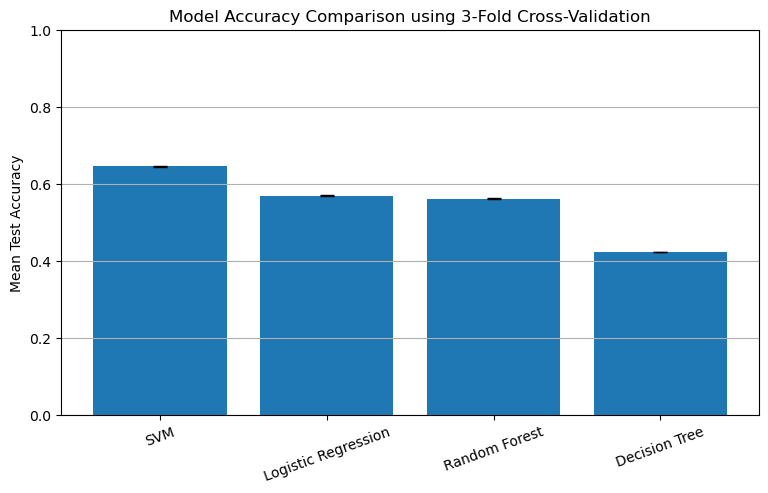

In [112]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Mean Test Accuracy"],
    yerr=results_df["Std Test Accuracy"],
    capsize=5
)

plt.ylabel("Mean Test Accuracy")
plt.title("Model Accuracy Comparison using 3-Fold Cross-Validation")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.show()

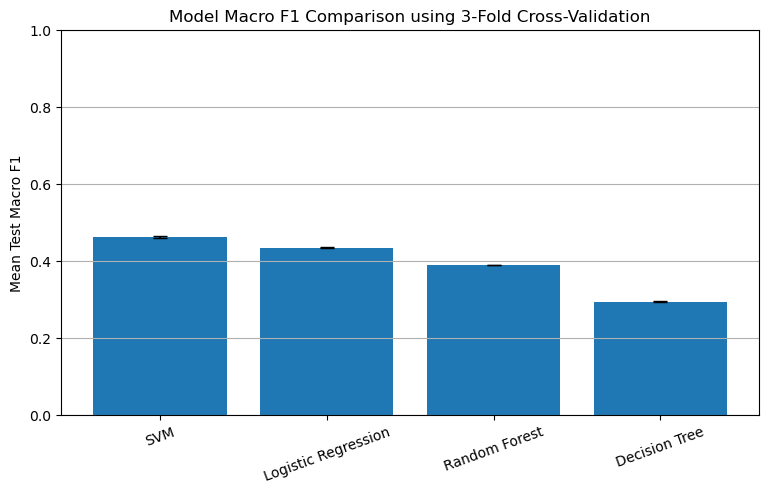

In [113]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Mean Test F1 Macro"],
    yerr=results_df["Std Test F1 Macro"],
    capsize=5
)

plt.ylabel("Mean Test Macro F1")
plt.title("Model Macro F1 Comparison using 3-Fold Cross-Validation")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.show()

In [114]:
svm_pipeline.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(class_weight='balanced',
                                                            max_iter=5000,
                                                            random_state=42)))])

In [115]:
y_train_pred = svm_pipeline.predict(x_train)
y_test_pred = svm_pipeline.predict(x_test)

In [116]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [117]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9257
Testing Accuracy: 0.6574


In [118]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__estimator__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best C:", grid.best_params_)
print("Best macro F1:", grid.best_score_)

Best C: {'clf__estimator__C': 0.1}
Best macro F1: 0.4634041124434229


In [119]:
best_svm = grid.best_estimator_

In [120]:
best_svm.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(C=0.1,
                                                            class_weight='balanced',
                                                            max_iter=5000,
                                                            random_state=42)))])

In [121]:
y_train_pred = best_svm.predict(x_train)
y_test_pred = best_svm.predict(x_test)

In [122]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [123]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7607
Testing Accuracy: 0.6334


In [124]:
# comparing the logistic regression model vs SVM

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best C:", grid.best_params_)
print("Best macro F1:", grid.best_score_)

best_log = grid.best_estimator_
best_log.fit(x_train, y_train)

y_train_pred = best_log.predict(x_train)
y_test_pred = best_log.predict(x_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy of LogReg: {train_accuracy:.4f}")
print(f"Testing Accuracy of LogReg: {test_accuracy:.4f}")

Best C: {'clf__C': 10}
Best macro F1: 0.45478576230122086
Training Accuracy of LogReg: 0.8916
Testing Accuracy of LogReg: 0.6234


In [125]:
subject_classes = best_svm.named_steps["clf"].classes_

def thesis_subject_votes(thesis, top_k=5):
    if pd.isna(thesis) or thesis is None:
        return Counter()
    
    probs = best_svm.predict_proba([thesis])[0]
    
    top_indices = probs.argsort()[::-1][:top_k]
    
    votes = Counter()
    for i in top_indices:
        votes[subject_classes[i]] = probs[i]
    
    return votes

In [126]:
def normalize_votes(votes):
    total = sum(votes.values())
    
    if total == 0:
        return Counter()
    
    return Counter({k: v / total for k, v in votes.items()})


def reliability_from_votes(votes, cap=5):
    """
    Measures how much evidence there is.
    
    If total evidence is small, reliability is small.
    If total evidence reaches cap, reliability becomes 1.
    """
    total = sum(votes.values())
    
    if total == 0:
        return 0.0
    
    return min(total / cap, 1.0)

In [127]:
def infer_subject_for_id(
    person_id,
    thesis,
    id_to_subject,
    id_to_advisors,
    id_to_students,
    max_depth=2,
    w_descendants=0.40,
    w_ancestors=0.20,
    w_thesis=0.40,
    descendant_reliability_cap=5,
    ancestor_reliability_cap=3
):
    # Raw votes
    raw_descendant_votes = collect_subjects_from_neighbors(
        person_id,
        id_to_students,
        id_to_subject,
        max_depth=max_depth
    )
    
    raw_ancestor_votes = collect_subjects_from_neighbors(
        person_id,
        id_to_advisors,
        id_to_subject,
        max_depth=max_depth
    )
    
    raw_thesis_votes = thesis_subject_votes(thesis)
    
    # Reliability factors
    rel_descendants = reliability_from_votes(
        raw_descendant_votes,
        cap=descendant_reliability_cap
    )
    
    rel_ancestors = reliability_from_votes(
        raw_ancestor_votes,
        cap=ancestor_reliability_cap
    )
    
    rel_thesis = 1.0 if raw_thesis_votes else 0.0
    
    # Normalize each source separately
    descendant_probs = normalize_votes(raw_descendant_votes)
    ancestor_probs = normalize_votes(raw_ancestor_votes)
    thesis_probs = normalize_votes(raw_thesis_votes)
    
    # Combine normalized evidence
    total_votes = Counter()
    
    for code, score in descendant_probs.items():
        total_votes[code] += w_descendants * rel_descendants * score
    
    for code, score in ancestor_probs.items():
        total_votes[code] += w_ancestors * rel_ancestors * score
    
    for code, score in thesis_probs.items():
        total_votes[code] += w_thesis * rel_thesis * score
    
    if not total_votes:
        return None, 0.0, {}, {
            "raw_descendant_votes": dict(raw_descendant_votes),
            "raw_ancestor_votes": dict(raw_ancestor_votes),
            "raw_thesis_votes": dict(raw_thesis_votes),
            "descendant_reliability": rel_descendants,
            "ancestor_reliability": rel_ancestors,
            "thesis_reliability": rel_thesis
        }
    
    best_code, best_score = total_votes.most_common(1)[0]
    
    total_score = sum(total_votes.values())
    confidence = best_score / total_score if total_score > 0 else 0.0
    
    details = {
        "raw_descendant_votes": dict(raw_descendant_votes),
        "raw_ancestor_votes": dict(raw_ancestor_votes),
        "raw_thesis_votes": dict(raw_thesis_votes),
        "descendant_probs": dict(descendant_probs),
        "ancestor_probs": dict(ancestor_probs),
        "thesis_probs": dict(thesis_probs),
        "descendant_reliability": rel_descendants,
        "ancestor_reliability": rel_ancestors,
        "thesis_reliability": rel_thesis
    }
    
    return best_code, confidence, dict(total_votes), details

In [128]:
missing_mask = tree["subject_code"].isna()

results = tree.loc[missing_mask].apply(
    lambda row: infer_subject_for_id(
        person_id=row["id"],
        thesis=row["thesis"],
        id_to_subject=id_to_subject,
        id_to_advisors=id_to_advisors,
        id_to_students=id_to_students,
        max_depth=3
    ),
    axis=1
)

tree.loc[missing_mask, "predicted_subject_code"] = results.apply(lambda x: x[0])
tree.loc[missing_mask, "subject_prediction_confidence"] = results.apply(lambda x: x[1])
tree.loc[missing_mask, "subject_prediction_votes"] = results.apply(lambda x: x[2])

In [129]:
tree.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None,34,0.684818,"{'81': 0.05555555555555555, '34': 0.3119724575..."
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,91,0.524447,"{'85': 0.022222222222222223, '91': 0.221433208..."
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None,74,0.871422,"{'85': 0.022222222222222223, '74': 0.367933795..."


In [130]:
subjects.loc[subjects["subject_Code"] == "34"]

,subject_Code,subject_Name,subject_Name_clean
23,34,Ordinary differential equations,ordinary differential equations


In [131]:
tree["final_subject_code"] = tree["subject_code"]

tree.loc[
    tree["final_subject_code"].isna(),
    "final_subject_code"
] = tree.loc[
    tree["final_subject_code"].isna(),
    "predicted_subject_code"
]

In [132]:
tree = tree.merge(
    subjects,
    left_on="final_subject_code",
    right_on="subject_Code",
    how="left",
    suffixes=("", "_from_table")
)

In [133]:
tree.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes,final_subject_code,subject_Code,subject_Name,subject_Name_clean
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN,74,74,Mechanics of deformable solids,mechanics of deformable solids
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",None,None,34,0.684818,"{'81': 0.05555555555555555, '34': 0.3119724575...",34,34,Ordinary differential equations,ordinary differential equations
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,91,0.524447,"{'85': 0.022222222222222223, '91': 0.221433208...",91,91,"Game theory, economics, social and behavioral ...",game theory economics social and behavioral sc...
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN,74,74,Mechanics of deformable solids,mechanics of deformable solids
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],None,None,74,0.871422,"{'85': 0.022222222222222223, '74': 0.367933795...",74,74,Mechanics of deformable solids,mechanics of deformable solids


In [134]:
filled_tree = tree.copy()

threshold = 0.55

mask = (
    filled_tree["subject_code"].isna() &
    filled_tree["predicted_subject_code"].notna() &
    (filled_tree["subject_prediction_confidence"] > threshold)
)

# Fill subject_code from prediction
filled_tree.loc[mask, "subject_code"] = filled_tree.loc[mask, "predicted_subject_code"]

# Fill subject_name from subjects_df
code_to_name = dict(
    zip(subjects["subject_Code"], subjects["subject_Name"])
)

filled_tree.loc[mask, "subject_name"] = (
    filled_tree.loc[mask, "subject_code"].map(code_to_name)
)

filled_tree.head()

,id,name,thesis,school,country,year,subject,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_votes,final_subject_code,subject_Code,subject_Name,subject_Name_clean
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,74—Mechanics of deformable solids,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN,74,74,Mechanics of deformable solids,mechanics of deformable solids
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,None,[239],"[19930, 19939]",34,Ordinary differential equations,34,0.684818,"{'81': 0.05555555555555555, '34': 0.3119724575...",34,34,Ordinary differential equations,ordinary differential equations
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,None,[258],[],None,None,91,0.524447,"{'85': 0.022222222222222223, '91': 0.221433208...",91,91,"Game theory, economics, social and behavioral ...",game theory economics social and behavioral sc...
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,74—Mechanics of deformable solids,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN,74,74,Mechanics of deformable solids,mechanics of deformable solids
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,None,[258],[],74,Mechanics of deformable solids,74,0.871422,"{'85': 0.022222222222222223, '74': 0.367933795...",74,74,Mechanics of deformable solids,mechanics of deformable solids


In [135]:
print("Rows filled:", mask.sum())

Rows filled: 77711


In [136]:
filled_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307400 non-null  object 
 3   school                         281806 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   subject                        202492 non-null  object 
 7   advisors                       338532 non-null  object 
 8   students                       338532 non-null  object 
 9   subject_code                   280203 non-null  object 
 10  subject_name                   280203 non-null  object 
 11  predicted_subject_code         130825 non-null  object 
 12  subject_prediction_confidence 

In [137]:
saving_file = pd.DataFrame()
saving_file["id"] = filled_tree["id"]
saving_file["name"] = filled_tree["name"]
saving_file["thesis"] = filled_tree["thesis"]   
saving_file["school"] = filled_tree["school"]
saving_file["country"] = filled_tree["country"]
saving_file["year"] = filled_tree["year"]
saving_file["advisors"] = filled_tree["advisors"]
saving_file["students"] = filled_tree["students"]
saving_file["subject_code"] = filled_tree["subject_code"]   
saving_file["subject_name"] = filled_tree["subject_name"]
saving_file["predicted_subject_code"] = filled_tree["predicted_subject_code"]
saving_file["subject_prediction_confidence"] = filled_tree["subject_prediction_confidence"]
saving_file["subject_prediction_vector"] = filled_tree["subject_prediction_votes"]

In [139]:
saving_file.head(10)

,id,name,thesis,school,country,year,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence,subject_prediction_vector
0,1,Ernest Willard Anderson,Statics of Special Types of Homogeneous Elasti...,Iowa State University,UnitedStates,1933.0,[258],"[11, 28, 31]",74,Mechanics of deformable solids,NaN,NaN,NaN
1,4,Charles Joseph Thorne,The Approximate Solution of Linear Differentia...,Iowa State University,UnitedStates,1941.0,[239],"[19930, 19939]",34,Ordinary differential equations,34,0.684818,"{'81': 0.05555555555555555, '34': 0.3119724575..."
2,5,Ralph Harry Tripp,Statical Equilibrium of Skew and Sector-Shaped...,Iowa State University,UnitedStates,1942.0,[258],[],None,None,91,0.524447,"{'85': 0.022222222222222223, '91': 0.221433208..."
3,2,Archie Higdon,Stresses in Moderately Thick Rectangular Plates,Iowa State University,UnitedStates,1936.0,[258],[],74,Mechanics of deformable solids,NaN,NaN,NaN
4,3,Donald Hill Rock,Finite Strain Analysis in Elastic Theory,Iowa State University,UnitedStates,1939.0,[258],[],74,Mechanics of deformable solids,74,0.871422,"{'85': 0.022222222222222223, '74': 0.367933795..."
5,6,William B. Stiles,Solutions of Clamped Plated Problems by Means ...,Iowa State University,UnitedStates,1945.0,[258],[],None,None,35,0.272181,"{'85': 0.022222222222222223, '35': 0.114921049..."
6,9,Henry David Block,Explicit Solutions of Certain Singular Integra...,Iowa State University,UnitedStates,1949.0,[281],"[23, 28, 71, 101996, 87826]",None,None,68,0.420147,"{'92': 0.054545454545454564, '68': 0.345454545..."
7,8,James W. Beach,Flow of Viscous Fluid between Slowing Rotating...,Iowa State University,UnitedStates,1948.0,[258],[],76,Fluid mechanics,76,0.863589,"{'85': 0.022222222222222223, '76': 0.364626373..."
8,7,Carl Eric Langenhop,Properties of Kernels of Integral Equations Wh...,Iowa State University,UnitedStates,1948.0,[281],"[48, 104689, 38, 33, 3026, 39, 32, 35]",None,None,45,0.547841,"{'05': 0.05333333333333334, '11': 0.0222222222..."
9,10,Frank E. Bortle,Analytical Study of Dynamic Loads on Elastical...,Iowa State University,UnitedStates,1949.0,[258],[],None,None,68,0.329157,"{'85': 0.022222222222222223, '68': 0.138977254..."


In [140]:
saving_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307400 non-null  object 
 3   school                         281806 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  object 
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  object 
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

In [141]:
saving_file.to_csv('../../data/processed/version2_new_dataset_fitted.csv', index=False)

In [142]:
saving_file.loc[saving_file["subject_code"].isna() & (saving_file.year >=2000)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 11455 entries, 800 to 338272
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             11455 non-null  int64  
 1   name                           11455 non-null  object 
 2   thesis                         10472 non-null  object 
 3   school                         11455 non-null  object 
 4   country                        11184 non-null  object 
 5   year                           11455 non-null  float64
 6   advisors                       11455 non-null  object 
 7   students                       11455 non-null  object 
 8   subject_code                   0 non-null      object 
 9   subject_name                   0 non-null      object 
 10  predicted_subject_code         10695 non-null  object 
 11  subject_prediction_confidence  11455 non-null  float64
 12  subject_prediction_vector      11455 non-null  o